# SASRec (Self-Attentive Sequential Recommendation) — Algorithm 2

SASRec models the user's sequential interaction history using a Transformer-style self-attention mechanism to predict the next item a user is likely to interact with.

Features: user interaction sequences ordered by timestamp, item ID embeddings, positional embeddings.

## Part 1: Environment Setup

### Part 1.1: Imports & Random Seed

In [52]:
import random
import numpy as np
import torch
import torch.nn as nn

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"Random seed set to {SEED}")

Random seed set to 42


### Part 1.2: Device Check (CPU / GPU)

In [53]:

if torch.cuda.is_available():
    DEVICE = torch.device("cuda:0")
    print(f"GPU available: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    DEVICE = torch.device("cpu")
    print("No GPU found — running on CPU.")

print(f"Device: {DEVICE}")


GPU available: NVIDIA GeForce RTX 4090
Memory: 25.3 GB
Device: cuda:0


### Part 1.3: Hyperparameters

In [57]:

# --- Sequence ---
MAX_SEQ_LEN  = 100     # increased from 50: median user history is 60, 75th pct is 133

# --- Model architecture ---
D_MODEL      = 64       # reduced from 128: only 485 users, smaller model avoids overfitting
NUM_HEADS    = 2       # number of self-attention heads (D_MODEL must be divisible)
NUM_BLOCKS   = 2       # reduced from 3: fewer layers suit small-medium datasets
DROPOUT      = 0.3     # increased from 0.2: stronger regularisation for small dataset

# --- Training ---
LR           = 1e-3    # Adam learning rate
EPOCHS       = 50      # maximum training epochs
PATIENCE     = 5       # early stopping patience (epochs without HR@10 improvement)
BATCH_SIZE   = 128     # reduced from 256: more gradient steps per epoch (~4 batches vs ~2)
NEG_SAMPLES  = 20      # increased from 4: more negatives sharpen ranking in sampled softmax CE
TEMPERATURE  = 0.1     # reduced from 0.07: 0.07 too aggressive for recsys scale, saturates early

# --- Evaluation ---
TOP_K        = 10      # cut-off for HR@K and NDCG@K
ALPHA = 0.65   # weight for nDCG in composite score

# --- Reproducibility ---
RANDOM_STATE = SEED

print("Hyperparameters:")
for name, val in [
    ("MAX_SEQ_LEN", MAX_SEQ_LEN), ("D_MODEL", D_MODEL), ("NUM_HEADS", NUM_HEADS),
    ("NUM_BLOCKS", NUM_BLOCKS), ("DROPOUT", DROPOUT), ("LR", LR),
    ("EPOCHS", EPOCHS), ("PATIENCE", PATIENCE), ("BATCH_SIZE", BATCH_SIZE),
    ("NEG_SAMPLES", NEG_SAMPLES), ("TOP_K", TOP_K), ("TEMPERATURE", TEMPERATURE),
]:
    print(f"  {name:<15} = {val}")


Hyperparameters:
  MAX_SEQ_LEN     = 100
  D_MODEL         = 64
  NUM_HEADS       = 2
  NUM_BLOCKS      = 2
  DROPOUT         = 0.3
  LR              = 0.001
  EPOCHS          = 50
  PATIENCE        = 5
  BATCH_SIZE      = 128
  NEG_SAMPLES     = 20
  TOP_K           = 10
  TEMPERATURE     = 0.1


## Part 2: Load Data & Preprocessing

### Part 2.1: Load CSVs

Load the ratings CSV **keeping the `timestamp` column** — SASRec requires interaction order. Movie metadata is loaded for later use at inference time.

In [58]:
import os
import pandas as pd

DATA_DIR = os.path.join(os.path.abspath(".."), "flaskr", "static", "ml_data")

# Keep timestamp — critical for building ordered sequences
ratings_df = pd.read_csv(os.path.join(DATA_DIR, "ratings.csv"))
movies_df  = pd.read_csv(os.path.join(DATA_DIR, "movie_info.csv"))

print(f"Ratings : {ratings_df.shape}  |  columns: {list(ratings_df.columns)}")
print(f"Movies  : {movies_df.shape}   |  columns: {list(movies_df.columns)}")
print()
print(ratings_df.head(3))

Ratings : (60141, 4)  |  columns: ['userId', 'movieId', 'rating', 'timestamp']
Movies  : (5446, 7)   |  columns: ['Unnamed: 0', 'movieId', 'title', 'genres', 'year', 'overview', 'cover_url']

   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1       70     3.0  964982400


### Part 2.2: ID Encoding

Encode `userId` and `movieId` to contiguous integer indices.  
Item indices start from **1** — index **0** is reserved as the padding token.

In [59]:
from sklearn.preprocessing import LabelEncoder

user_enc = LabelEncoder()
item_enc = LabelEncoder()

ratings_df["user_idx"] = user_enc.fit_transform(ratings_df["userId"])
ratings_df["item_idx"] = item_enc.fit_transform(ratings_df["movieId"]) + 1  # 0 = padding

NUM_USERS = int(ratings_df["user_idx"].nunique())
NUM_ITEMS = int(ratings_df["item_idx"].nunique()) + 1  # +1 for padding index 0

print(f"Unique users : {NUM_USERS}")
print(f"Unique items : {NUM_ITEMS - 1}  (vocab size incl. pad token: {NUM_ITEMS})")

Unique users : 485
Unique items : 5553  (vocab size incl. pad token: 5554)


### Part 2.3: Build Interaction Sequences

Sort each user's ratings by timestamp to produce a **chronologically ordered** item sequence per user.

In [60]:
# Sort globally by user then timestamp, then group into per-user sequences
ratings_sorted = ratings_df.sort_values(["user_idx", "timestamp"])
user_sequences = (
    ratings_sorted.groupby("user_idx")["item_idx"]
    .apply(list)
    .to_dict()
)

lengths = [len(v) for v in user_sequences.values()]
print(f"Users with sequences : {len(user_sequences)}")
print(f"Sequence length  —  min: {min(lengths)},  max: {max(lengths)},  "
      f"median: {int(np.median(lengths))},  mean: {np.mean(lengths):.1f}")

Users with sequences : 485
Sequence length  —  min: 20,  max: 1698,  median: 60,  mean: 124.0


### Part 2.4: Sequence Construction & Padding

**Leave-one-out split** (standard for SASRec evaluation):
- **Validation**: input = all items except the last → target = last item  
- **Training**: from the remaining history, input[t] → next-item label[t] at every position  

Sequences shorter than `MAX_SEQ_LEN` are **left-padded** with zeros; longer ones are **right-truncated** (keep the most recent interactions).  
Users with fewer than 3 interactions are skipped.

In [61]:
def pad_or_truncate(seq, max_len, pad_val=0):
    """Left-pad with pad_val, or truncate to keep the most recent max_len items."""
    seq = list(seq)
    if len(seq) >= max_len:
        return seq[-max_len:]
    return [pad_val] * (max_len - len(seq)) + seq

train_seqs     = []   # padded input sequences          shape (N, MAX_SEQ_LEN)
train_pos      = []   # padded positive next-item seqs  shape (N, MAX_SEQ_LEN)
val_seqs       = []   # padded input sequences for val  shape (M, MAX_SEQ_LEN)
val_targets    = []   # single target item per val user  shape (M,)
user_histories = {}   # user_idx -> set of all interacted item indices (for neg. sampling)

for user_idx, seq in user_sequences.items():
    if len(seq) < 3:   # need at least 3 interactions for a meaningful split
        continue

    user_histories[user_idx] = set(seq)

    # --- Validation sample ---
    # Input: everything except the last item; target: last item
    val_seqs.append(pad_or_truncate(seq[:-1], MAX_SEQ_LEN))
    val_targets.append(seq[-1])

    # --- Training sample ---
    # Exclude the last item (reserved for val), then build next-item prediction pairs:
    #   position t: input = history up to t, label = item at t+1
    train_seq = seq[:-1]
    train_seqs.append(pad_or_truncate(train_seq[:-1], MAX_SEQ_LEN))  # input
    train_pos.append( pad_or_truncate(train_seq[1:],  MAX_SEQ_LEN))  # next-item labels

train_seqs  = np.array(train_seqs,  dtype=np.int64)
train_pos   = np.array(train_pos,   dtype=np.int64)
val_seqs    = np.array(val_seqs,    dtype=np.int64)
val_targets = np.array(val_targets, dtype=np.int64)

print(f"Training samples   : {train_seqs.shape}")
print(f"Validation samples : {val_seqs.shape}")
print(f"Users skipped (seq < 3): {len(user_sequences) - len(val_targets)}")

Training samples   : (485, 100)
Validation samples : (485, 100)
Users skipped (seq < 3): 0


### Part 2.5: Dataset Summary

In [62]:
# Fraction of non-padding positions (higher = denser sequences)
train_density = (train_pos != 0).sum() / train_pos.size
val_density   = (val_seqs  != 0).sum() / val_seqs.size

print("=" * 45)
print("  Dataset Summary")
print("=" * 45)
print(f"  Users (train/val)  : {len(train_seqs):>7,}")
print(f"  Item vocabulary    : {NUM_ITEMS:>7,}  (incl. pad)")
print(f"  Sequence length    : {MAX_SEQ_LEN:>7}")
print(f"  Train non-pad ratio: {train_density:>7.1%}")
print(f"  Val   non-pad ratio: {val_density:>7.1%}")
print("=" * 45)
print(f"\nSample train input  : {train_seqs[0]}")
print(f"Sample train labels : {train_pos[0]}")
print(f"Sample val target   : {val_targets[0]}")

  Dataset Summary
  Users (train/val)  :     485
  Item vocabulary    :   5,554  (incl. pad)
  Sequence length    :     100
  Train non-pad ratio:   62.4%
  Val   non-pad ratio:   63.1%

Sample train input  : [ 485  524  401 1556  459  471  918 1219  880  928 1188  888 1481  865
  329  946 1484  801 1460 1461  507 1616  855 1256  510  544   57  817
 1254 1255  841 1277 1275 1505  535  662  159  958 1024 1088  247   38
 1593 1349 1032  893  303  178  323  862  883 1055  657  720 1049 1128
  442  582  438    1  539  326  441  309  465  690  153 1110  598  692
  760 1123 1375 1014  413  506  983 1259  537  468 1430  698 1391  989
  528   78  967  530 1574 1294  995  273  466   68 1466  548   72  618
  290 1062]
Sample train labels : [ 524  401 1556  459  471  918 1219  880  928 1188  888 1481  865  329
  946 1484  801 1460 1461  507 1616  855 1256  510  544   57  817 1254
 1255  841 1277 1275 1505  535  662  159  958 1024 1088  247   38 1593
 1349 1032  893  303  178  323  862  883 1055  

## Part 3: SASRec Model

### Part 3.0 — Model Architecture

In [63]:

import math
import torch.nn as nn
import torch.nn.functional as F

# ── Point-wise Feed-Forward ──────────────────────────────────────────────────
class PointWiseFeedForward(nn.Module):
    def __init__(self, d_model, dropout=0.2):
        super().__init__()
        self.fc1     = nn.Linear(d_model, d_model * 4)
        self.fc2     = nn.Linear(d_model * 4, d_model)
        self.dropout = nn.Dropout(dropout)
        self.act     = nn.GELU()

    def forward(self, x):
        return self.fc2(self.dropout(self.act(self.fc1(x))))


# ── Single Transformer Block ─────────────────────────────────────────────────
class SASRecBlock(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.2):
        super().__init__()
        self.attn = nn.MultiheadAttention(d_model, num_heads,
                                          dropout=dropout, batch_first=True)
        self.ffn  = PointWiseFeedForward(d_model, dropout)
        self.ln1  = nn.LayerNorm(d_model)
        self.ln2  = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, attn_mask=None, key_padding_mask=None):
        # Self-attention with pre-LN + residual
        residual = x
        x = self.ln1(x)
        x, _ = self.attn(x, x, x,
                         attn_mask=attn_mask,
                         key_padding_mask=key_padding_mask,
                         need_weights=False)
        x = self.drop(x) + residual
        # FFN with pre-LN + residual
        residual = x
        x = self.ln2(x)
        x = self.ffn(x) + residual
        return x


# ── SASRec ───────────────────────────────────────────────────────────────────
class SASRec(nn.Module):
    def __init__(self, num_items, d_model, num_heads, num_blocks,
                 max_seq_len, dropout=0.2):
        super().__init__()
        self.item_emb    = nn.Embedding(num_items, d_model, padding_idx=0)
        self.pos_emb     = nn.Embedding(max_seq_len + 1, d_model)   # 1-indexed
        self.dropout     = nn.Dropout(dropout)
        self.blocks      = nn.ModuleList([
            SASRecBlock(d_model, num_heads, dropout) for _ in range(num_blocks)
        ])
        self.ln_out      = nn.LayerNorm(d_model)
        self.max_seq_len = max_seq_len
        self._init_weights()

    def _init_weights(self):
        nn.init.normal_(self.item_emb.weight, std=0.02)
        nn.init.normal_(self.pos_emb.weight,  std=0.02)

    def forward(self, seq):
        """seq : (B, L) — item indices, 0 = padding → returns (B, L, D)"""
        B, L = seq.shape
        positions = torch.arange(1, L + 1, device=seq.device).unsqueeze(0).expand(B, -1)

        x = self.dropout(self.item_emb(seq) + self.pos_emb(positions))

        # Causal (autoregressive) mask — upper-triangular True = blocked
        causal_mask = torch.triu(
            torch.ones(L, L, device=seq.device, dtype=torch.bool), diagonal=1
        )
        pad_mask = (seq == 0)   # (B, L), True where padding

        for block in self.blocks:
            x = block(x, attn_mask=causal_mask, key_padding_mask=pad_mask)

        return self.ln_out(x)   # (B, L, D)

    def predict(self, seq, candidate_items):
        """
        seq             : (B, L)
        candidate_items : (B, C)
        returns scores  : (B, C)  — cosine similarities in [-1, 1]
        """
        h_last   = F.normalize(self.forward(seq)[:, -1, :], dim=-1)  # (B, D) unit vector
        cand_emb = F.normalize(self.item_emb(candidate_items), dim=-1)  # (B, C, D) unit vectors
        return torch.bmm(cand_emb, h_last.unsqueeze(-1)).squeeze(-1)     # (B, C) cosine sim

print("SASRec model class defined ✓")


SASRec model class defined ✓


### Part 3.1 — Model Setup

In [64]:
model = SASRec(
    num_items   = NUM_ITEMS,
    d_model     = D_MODEL,
    num_heads   = NUM_HEADS,
    num_blocks  = NUM_BLOCKS,
    max_seq_len = MAX_SEQ_LEN,
    dropout     = DROPOUT,
).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")
print()
print(model)

Total parameters     : 462,016
Trainable parameters : 462,016

SASRec(
  (item_emb): Embedding(5554, 64, padding_idx=0)
  (pos_emb): Embedding(101, 64)
  (dropout): Dropout(p=0.3, inplace=False)
  (blocks): ModuleList(
    (0-1): 2 x SASRecBlock(
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
      )
      (ffn): PointWiseFeedForward(
        (fc1): Linear(in_features=64, out_features=256, bias=True)
        (fc2): Linear(in_features=256, out_features=64, bias=True)
        (dropout): Dropout(p=0.3, inplace=False)
        (act): GELU(approximate='none')
      )
      (ln1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (ln2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (drop): Dropout(p=0.3, inplace=False)
    )
  )
  (ln_out): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
)


### Part 3.2 — Training Loop

In [65]:

from torch.utils.data import Dataset, DataLoader

print("Hyperparameters:")
for name, val in [
    ("MAX_SEQ_LEN", MAX_SEQ_LEN), ("D_MODEL", D_MODEL), ("NUM_HEADS", NUM_HEADS),
    ("NUM_BLOCKS", NUM_BLOCKS), ("DROPOUT", DROPOUT), ("LR", LR),
    ("EPOCHS", EPOCHS), ("PATIENCE", PATIENCE), ("BATCH_SIZE", BATCH_SIZE),
    ("NEG_SAMPLES", NEG_SAMPLES), ("TOP_K", TOP_K), ("TEMPERATURE", TEMPERATURE),
]:
    print(f"  {name:<15} = {val}")
print("-" * 90)


# ── Dataset: sample NEG_SAMPLES negatives per position ───────────────────────
class SASRecDataset(Dataset):
    def __init__(self, seqs, pos_seqs, user_id_list, user_histories, num_items):
        self.seqs           = seqs
        self.pos_seqs       = pos_seqs
        self.user_id_list   = user_id_list
        self.user_histories = user_histories
        self.num_items      = num_items

    def __len__(self):
        return len(self.seqs)

    def __getitem__(self, idx):
        seq = self.seqs[idx]
        pos = self.pos_seqs[idx]
        history = self.user_histories.get(self.user_id_list[idx], set())
        # NEG_SAMPLES negatives per position → shape (L, NEG_SAMPLES)
        neg = np.zeros((len(pos), NEG_SAMPLES), dtype=np.int64)
        for t in range(len(pos)):
            if pos[t] == 0:
                continue
            sampled = []
            while len(sampled) < NEG_SAMPLES:
                j = random.randint(1, self.num_items - 1)
                while j in history:
                    j = random.randint(1, self.num_items - 1)
                sampled.append(j)
            neg[t] = sampled
        return (
            torch.tensor(seq, dtype=torch.long),
            torch.tensor(pos, dtype=torch.long),
            torch.tensor(neg, dtype=torch.long),
        )


# ── Derive per-user training targets ─────────────────────────────────────────
train_targets = np.array([
    pos[pos != 0][-1] if (pos != 0).any() else 0
    for pos in train_pos
], dtype=np.int64)


# ── Composite score ───────────────────────────────────────────────────────────
def composite_score(hr, ndcg, alpha=ALPHA):
    return alpha * ndcg + (1 - alpha) * hr


# ── Combined evaluation: HR@K, NDCG@K, BCE loss, Composite ───────────────────
# predict() now returns cosine similarities — no need to rescale by sqrt(D_MODEL)
def evaluate_model(model, seqs, targets, user_id_list,
                   user_histories, num_items, top_k, device, num_neg=99,
                   seed=SEED):
    model.eval()
    hr_list, ndcg_list, loss_list = [], [], []
    bce = nn.BCEWithLogitsLoss()
    rng = random.Random(seed)

    with torch.no_grad():
        for i in range(len(seqs)):
            target = int(targets[i])
            if target == 0:
                continue
            history = user_histories.get(user_id_list[i], set())

            negs = []
            while len(negs) < num_neg:
                j = rng.randint(1, num_items - 1)
                if j not in history and j != target:
                    negs.append(j)

            seq    = torch.tensor(seqs[i], dtype=torch.long).unsqueeze(0).to(device)
            cands  = torch.tensor([target] + negs, dtype=torch.long).unsqueeze(0).to(device)
            scores = model.predict(seq, cands).squeeze(0)   # cosine sim, no extra scaling

            labels    = torch.zeros(1 + num_neg, device=device)
            labels[0] = 1.0
            l = bce(scores, labels).item()
            if not math.isnan(l):
                loss_list.append(l)

            _, top_indices = scores.topk(top_k)
            rank_tensor = (top_indices == 0).nonzero(as_tuple=True)[0]
            if len(rank_tensor):
                r = rank_tensor[0].item() + 1
                hr_list.append(1.0)
                ndcg_list.append(1.0 / math.log2(r + 1))
            else:
                hr_list.append(0.0)
                ndcg_list.append(0.0)

    hr   = float(np.mean(hr_list))   if hr_list   else 0.0
    ndcg = float(np.mean(ndcg_list)) if ndcg_list else 0.0
    loss = float(np.mean(loss_list)) if loss_list else float("nan")
    comp = composite_score(hr, ndcg)
    return hr, ndcg, loss, comp


# ── Build ordered user-id list ────────────────────────────────────────────────
user_id_list = [uid for uid, seq in user_sequences.items() if len(seq) >= 3]

dataset = SASRecDataset(train_seqs, train_pos, user_id_list, user_histories, NUM_ITEMS)
loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False,
                     num_workers=0, pin_memory=(DEVICE.type == "cuda"))

optimizer = torch.optim.Adam(model.parameters(), lr=LR, betas=(0.9, 0.98))

# ── Scheduler: halve LR after 5 epochs without comp improvement ──────────────
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=5
)

WARMUP_EPOCHS = 10   # early stopping won't trigger before this epoch
ES_PATIENCE   = 10   # early stopping patience
LR_PATIENCE   = 5    # already set in scheduler above

best_comp   = 0.0
patience_ct = 0
history_log = {
    "epoch"     : [],
    "train_loss": [], "train_hr": [], "train_ndcg": [], "train_comp": [],
    "val_loss"  : [], "val_hr"  : [], "val_ndcg"  : [], "val_comp"  : [],
}

# Header
print(f"{'Epoch':>5}  {'LR':>8}  "
      f"{'TrLoss':>7}  {'TrHR':>6}  {'TrNDCG':>7}  {'TrComp':>7}  "
      f"{'VaLoss':>7}  {'VaHR':>6}  {'VaNDCG':>7}  {'VaComp':>7}")
print("-" * 90)

for epoch in range(1, EPOCHS + 1):
    # ── Training pass: cosine similarity + temperature-scaled softmax CE ──────
    model.train()
    running_loss = 0.0

    for seq, pos, neg in loader:
        seq, pos, neg = seq.to(DEVICE), pos.to(DEVICE), neg.to(DEVICE)
        # seq: (B, L), pos: (B, L), neg: (B, L, NEG_SAMPLES)
        optimizer.zero_grad()

        B, L = seq.shape
        h       = model(seq)                                         # (B, L, D)
        h_n     = F.normalize(h, dim=-1)                            # (B, L, D) unit vectors
        pos_emb = F.normalize(model.item_emb(pos), dim=-1)          # (B, L, D) unit vectors
        neg_emb = F.normalize(model.item_emb(neg), dim=-1)          # (B, L, K, D) unit vectors

        # Cosine similarities scaled by temperature
        pos_scores = (h_n * pos_emb).sum(-1, keepdim=True) / TEMPERATURE        # (B, L, 1)
        neg_scores = torch.einsum('bld,blnd->bln', h_n, neg_emb) / TEMPERATURE  # (B, L, K)

        # Sampled softmax CE: positive is always class index 0
        logits  = torch.cat([pos_scores, neg_scores], dim=-1)        # (B, L, 1+K)
        targets = torch.zeros(B, L, dtype=torch.long, device=DEVICE)
        mask    = (pos != 0)                                         # (B, L)

        loss = F.cross_entropy(logits[mask], targets[mask])
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        running_loss += loss.item()

    train_ce   = running_loss / len(loader)
    current_lr = optimizer.param_groups[0]["lr"]

    # ── Evaluate both splits ──────────────────────────────────────────────────
    tr_hr, tr_ndcg, tr_loss, tr_comp = evaluate_model(
        model, train_seqs, train_targets, user_id_list,
        user_histories, NUM_ITEMS, TOP_K, DEVICE
    )
    va_hr, va_ndcg, va_loss, va_comp = evaluate_model(
        model, val_seqs, val_targets, user_id_list,
        user_histories, NUM_ITEMS, TOP_K, DEVICE
    )

    # Log
    history_log["epoch"     ].append(epoch)
    history_log["train_loss"].append(train_ce)
    history_log["train_hr"  ].append(tr_hr)
    history_log["train_ndcg"].append(tr_ndcg)
    history_log["train_comp"].append(tr_comp)
    history_log["val_loss"  ].append(va_loss)
    history_log["val_hr"    ].append(va_hr)
    history_log["val_ndcg"  ].append(va_ndcg)
    history_log["val_comp"  ].append(va_comp)

    # ── Step LR scheduler ─────────────────────────────────────────────────────
    scheduler.step(va_comp)

    # ── Checkpoint & early stopping ───────────────────────────────────────────
    is_best  = va_comp > best_comp
    ckpt_msg = "  ✓ best" if is_best else ""

    print(f"{epoch:>5}  {current_lr:>8.6f}  "
          f"{train_ce:>7.4f}  {tr_hr:>6.4f}  {tr_ndcg:>7.4f}  {tr_comp:>7.4f}  "
          f"{va_loss:>7.4f}  {va_hr:>6.4f}  {va_ndcg:>7.4f}  {va_comp:>7.4f}"
          f"{ckpt_msg}")

    if is_best:
        best_comp   = va_comp
        patience_ct = 0
        torch.save(model.state_dict(), "best_sasrec.pt")
    else:
        patience_ct += 1
        # Early stopping only triggers after warmup period
        if epoch > WARMUP_EPOCHS and patience_ct >= ES_PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}  "
                  f"(best Comp = {best_comp:.4f}, no improvement for {ES_PATIENCE} epochs)")
            break

print(f"\nTraining complete.  Best Val Composite: {best_comp:.4f}")


Hyperparameters:
  MAX_SEQ_LEN     = 100
  D_MODEL         = 64
  NUM_HEADS       = 2
  NUM_BLOCKS      = 2
  DROPOUT         = 0.3
  LR              = 0.001
  EPOCHS          = 50
  PATIENCE        = 5
  BATCH_SIZE      = 128
  NEG_SAMPLES     = 20
  TOP_K           = 10
  TEMPERATURE     = 0.1
------------------------------------------------------------------------------------------
Epoch        LR   TrLoss    TrHR   TrNDCG   TrComp   VaLoss    VaHR   VaNDCG   VaComp
------------------------------------------------------------------------------------------
    1  0.001000   3.4648  0.7773   0.2878   0.4591   0.6661  0.7691   0.2894   0.4573  ✓ best
    2  0.001000   2.4642  0.8165   0.3172   0.4919   0.6361  0.8021   0.3025   0.4774  ✓ best
    3  0.001000   1.9862  0.8186   0.3241   0.4971   0.6173  0.8165   0.3084   0.4862  ✓ best
    4  0.001000   1.9068  0.8082   0.3191   0.4903   0.6089  0.8124   0.3100   0.4858
    5  0.001000   1.9050  0.8268   0.3251   0.5007   0.6078  0.8165

### Part 3.3 — Final Evaluation

In [66]:
model.load_state_dict(torch.load("best_sasrec.pt", map_location=DEVICE))

hr_final, ndcg_final, loss_final, comp_final = evaluate_model(   # ← 4 values
    model, val_seqs, val_targets, user_id_list,
    user_histories, NUM_ITEMS, TOP_K, DEVICE
)

print("=" * 45)
print(f"  Final Validation Metrics  (top-{TOP_K})")
print("=" * 45)
print(f"  Loss       : {loss_final:.4f}")
print(f"  HR@{TOP_K}   : {hr_final:.4f}")
print(f"  NDCG@{TOP_K} : {ndcg_final:.4f}")
print(f"  Composite  : {comp_final:.4f}  (α={ALPHA} × nDCG + {1-ALPHA} × HR)")
print("=" * 45)

  Final Validation Metrics  (top-10)
  Loss       : 0.6223
  HR@10   : 0.8412
  NDCG@10 : 0.3328
  Composite  : 0.5108  (α=0.65 × nDCG + 0.35 × HR)


### Part 3.4 — Plot Training Curves

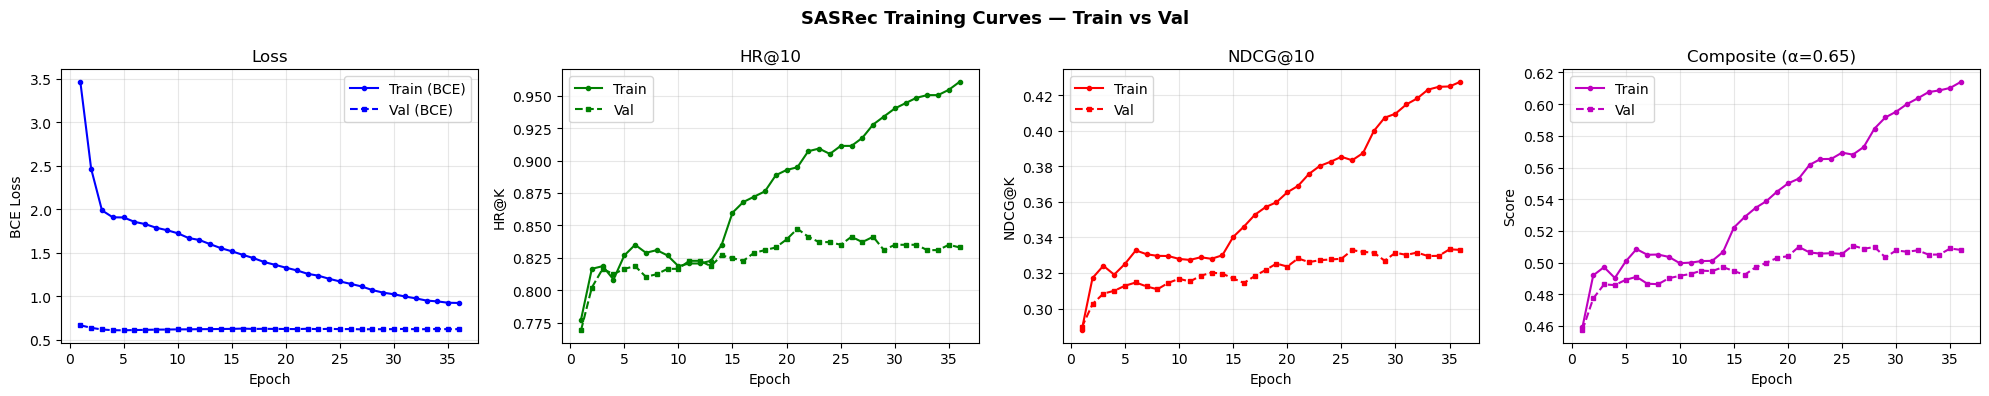

Training curves saved → training_curves_sasrec.png


In [67]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(20, 4))   # ← single declaration at top
epochs = history_log["epoch"]

# Loss
axes[0].plot(epochs, history_log["train_loss"], "b-o",  markersize=3, label="Train (BCE)")
axes[0].plot(epochs, history_log["val_loss"],   "b--s", markersize=3, label="Val (BCE)")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("BCE Loss")
axes[0].legend()

# HR
axes[1].plot(epochs, history_log["train_hr"],   "g-o",  markersize=3, label="Train")
axes[1].plot(epochs, history_log["val_hr"],     "g--s", markersize=3, label="Val")
axes[1].set_title(f"HR@{TOP_K}"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("HR@K")
axes[1].legend()

# NDCG
axes[2].plot(epochs, history_log["train_ndcg"], "r-o",  markersize=3, label="Train")
axes[2].plot(epochs, history_log["val_ndcg"],   "r--s", markersize=3, label="Val")
axes[2].set_title(f"NDCG@{TOP_K}"); axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("NDCG@K")
axes[2].legend()

# Composite
axes[3].plot(epochs, history_log["train_comp"], "m-o",  markersize=3, label="Train")
axes[3].plot(epochs, history_log["val_comp"],   "m--s", markersize=3, label="Val")
axes[3].set_title(f"Composite (α={ALPHA})"); axes[3].set_xlabel("Epoch"); axes[3].set_ylabel("Score")
axes[3].legend()

for ax in axes:
    ax.grid(alpha=0.3)

plt.suptitle("SASRec Training Curves — Train vs Val", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("training_curves_sasrec.png", dpi=150)
plt.show()
print("Training curves saved → training_curves_sasrec.png")

## Part 4: Save & Verify Weights

### Part 4.1 — Save Weights & Item Encoder

In [68]:
import pickle

WEIGHTS_PATH = os.path.join(DATA_DIR, "sasrec_weights.pt")
ENC_PATH     = os.path.join(DATA_DIR, "sasrec_item_enc.pkl")

torch.save(model.state_dict(), WEIGHTS_PATH)
print(f"Model weights saved  → {WEIGHTS_PATH}")

with open(ENC_PATH, "wb") as f:
    pickle.dump(item_enc, f)
print(f"Item encoder saved   → {ENC_PATH}")

# Also persist config values needed at serving time
MODEL_CONFIG = {
    "num_items":   NUM_ITEMS,
    "d_model":     D_MODEL,
    "num_heads":   NUM_HEADS,
    "num_blocks":  NUM_BLOCKS,
    "max_seq_len": MAX_SEQ_LEN,
    "dropout":     DROPOUT,
}
CONFIG_PATH = os.path.join(DATA_DIR, "sasrec_config.pkl")
with open(CONFIG_PATH, "wb") as f:
    pickle.dump(MODEL_CONFIG, f)
print(f"Model config saved   → {CONFIG_PATH}")

Model weights saved  → /home/comp/f3228660/COMP4135-RecSys/flaskr/static/ml_data/sasrec_weights.pt
Item encoder saved   → /home/comp/f3228660/COMP4135-RecSys/flaskr/static/ml_data/sasrec_item_enc.pkl
Model config saved   → /home/comp/f3228660/COMP4135-RecSys/flaskr/static/ml_data/sasrec_config.pkl


### Part 4.2 — Sanity Check: Reload & Dummy Forward Pass

In [69]:
with open(CONFIG_PATH, "rb") as f:
    cfg = pickle.load(f)

model_check = SASRec(**cfg).to(DEVICE)
model_check.load_state_dict(torch.load(WEIGHTS_PATH, map_location=DEVICE))
model_check.eval()

dummy_seq       = torch.zeros(2, MAX_SEQ_LEN, dtype=torch.long, device=DEVICE)
dummy_seq[0, -3:] = torch.tensor([10, 42, 99])   # user 0: last 3 items
dummy_seq[1, -1]  = 7                             # user 1: only 1 item

with torch.no_grad():
    out    = model_check(dummy_seq)                # (2, 50, 64)
    cands  = torch.arange(1, 11, device=DEVICE).unsqueeze(0).expand(2, -1)
    scores = model_check.predict(dummy_seq, cands) # (2, 10)

print(f"Forward pass output shape : {out.shape}")    # (2, 50, 64)
print(f"Predict scores shape      : {scores.shape}") # (2, 10)
print("Sanity check passed ✓")

Forward pass output shape : torch.Size([2, 100, 64])
Predict scores shape      : torch.Size([2, 10])
Sanity check passed ✓


## Part 5: Inference Helper

### Part 5.1 — predict_for_user

In [70]:

def predict_for_user(user_sequence_raw, top_k=TOP_K, exclude_seen=True):
    """
    Parameters
    ----------
    user_sequence_raw : list[int]
        Chronologically ordered raw movieId values for a user.
    top_k : int
        Number of recommendations to return.
    exclude_seen : bool
        Whether to mask out items the user has already interacted with.

    Returns
    -------
    list of (movieId, score) tuples, ranked by descending score.
    """
    model.eval()

    # 1. Encode raw movieIds → internal item indices (skip unknowns)
    known_mask = np.isin(user_sequence_raw, item_enc.classes_)
    known_ids  = np.array(user_sequence_raw)[known_mask]
    if len(known_ids) == 0:
        print("No recognised items in the provided history.")
        return []
    encoded = item_enc.transform(known_ids) + 1   # 1-indexed (0 = pad)

    # 2. Pad / truncate to MAX_SEQ_LEN
    seq_list   = pad_or_truncate(encoded.tolist(), MAX_SEQ_LEN)
    seq_tensor = torch.tensor(seq_list, dtype=torch.long).unsqueeze(0).to(DEVICE)

    # 3. Score all items using cosine similarity — consistent with training
    all_item_ids = torch.arange(1, NUM_ITEMS, dtype=torch.long, device=DEVICE)  # (V,)
    with torch.no_grad():
        h_last    = F.normalize(model(seq_tensor)[:, -1, :], dim=-1)   # (1, D) unit vector
        item_embs = F.normalize(model.item_emb(all_item_ids), dim=-1)  # (V, D) unit vectors
        scores_t  = (item_embs @ h_last.T).squeeze(-1)                 # (V,) cosine sim
    scores_np = scores_t.cpu().numpy()

    # 4. Optionally mask seen items
    if exclude_seen:
        for idx in encoded:                  # idx is 1-based
            scores_np[idx - 1] = -np.inf

    # 5. Top-K by score
    top_pos    = np.argpartition(scores_np, -top_k)[-top_k:]
    top_pos    = top_pos[np.argsort(scores_np[top_pos])[::-1]]
    top_item_idx = top_pos + 1                           # back to 1-indexed
    top_movie_ids = item_enc.inverse_transform(top_item_idx - 1)

    return list(zip(top_movie_ids.tolist(), scores_np[top_pos].tolist()))


### Part 5.2 — Test Inference on a Sample User

In [72]:

sample_uid  = user_id_list[0]   # integer user_idx

# Map user_idx → original userId (always present in raw CSV)
sample_user_id = user_enc.inverse_transform([sample_uid])[0]

raw_history = (
    ratings_df[ratings_df["userId"] == sample_user_id]
    .sort_values("timestamp")["movieId"]
    .tolist()
)

# Ground truth: movies this user rated 5.0
ground_truth = set(
    ratings_df[(ratings_df["userId"] == sample_user_id) & (ratings_df["rating"] >= 5.0)]
    ["movieId"].tolist()
)

# exclude_seen=False: allow recommendations to include seen items so the
# ground-truth overlap comparison is meaningful
recs = predict_for_user(raw_history, top_k=TOP_K, exclude_seen=False)
recommended_ids = [mid for mid, _ in recs]

hits = [mid for mid in recommended_ids if mid in ground_truth]

print(f"User index                  : {sample_uid}")
print(f"History len                 : {len(raw_history)} interactions")
print(f"Ground truth (rating = 5.0) : {len(ground_truth)} movies")
print(f"Hits in top-{TOP_K}          : {len(hits)}/{TOP_K}")
print(f"Precision@{TOP_K}            : {len(hits)/TOP_K:.2f}")
print()
print(f"Top-{TOP_K} recommendations  (✓ = rated 5.0 by this user):")
print(f"{'':>4}  {'Rank':>4}  {'movieId':>8}  {'Score':>8}  Title")
print("-" * 65)
for rank, (mid, score) in enumerate(recs, 1):
    title_arr = movies_df[movies_df["movieId"] == mid]["title"].values
    title     = title_arr[0] if len(title_arr) else "Unknown"
    hit_tag   = "✓" if mid in ground_truth else " "
    print(f"  {hit_tag}   {rank:>2}  {mid:>8}  {score:>8.4f}  {title}")


User index                  : 0
History len                 : 130 interactions
Ground truth (rating = 5.0) : 62 movies
Hits in top-10          : 1/10
Precision@10            : 0.10

Top-10 recommendations  (✓ = rated 5.0 by this user):
      Rank   movieId     Score  Title
-----------------------------------------------------------------
       1       480    0.5277  Jurassic Park
       2      3175    0.5213  Galaxy Quest
       3      2628    0.5191  Star Wars: Episode I - The Phantom Menace
  ✓    4      1073    0.5105  Willy Wonka & the Chocolate Factory
       5      2683    0.4952  Austin Powers: The Spy Who Shagged Me
       6       356    0.4909  Forrest Gump
       7      1375    0.4876  Star Trek III: The Search for Spock
       8      1377    0.4874  Batman Returns
       9       380    0.4822  True Lies
      10      1214    0.4781  Alien
